# **STAGE 2 - EDA AND DATA VISUALISATION**

## **Objectives**

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## **Inputs**

* Write down which data or information you need to run the notebook 

## **Outputs**

* Write here which files, code or artefacts you generate by the end of the notebook 

## **Additional Comments**

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

## **Change working directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis'

---

## **Import Packages and Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
sns.set_style("whitegrid")

---

## **Load Dataset**

In [5]:
# Load the cleaned dataset
df_vis = pd.read_csv("datasets/cleaned-data/student_performance_dataset_cleaned.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_vis.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,final_grade_category,final_grade_binary
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,High Grade,1
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,High Grade,1
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,High Grade,1
3,4,Male,2.6,77.5,8.0,Unknown,Yes,Yes,No,85.1,83.8,B,High Grade,1
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,Low Grade,0


---

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Explore Categorical Columns**

Given that we already looked at the distributions of numerical columns as part of the handling outliers section, it would be good to have a look at the categorical columns - what their values are and the frequency of each in the dataset.

The categorical columns are: `gender`, `parental_education`, `internet_access`, `extracurricular_activities`, `part_time_job`, `final_grade`.

I will be visualising the unique values and their frequencies in a countplot and pie chart for each categorical variable.

In [6]:
# Set the seaborn colour paletter "GnBu" to be used on the matplotlib pie charts
colours = sns.color_palette("GnBu")

#### **1.1.1 Gender**

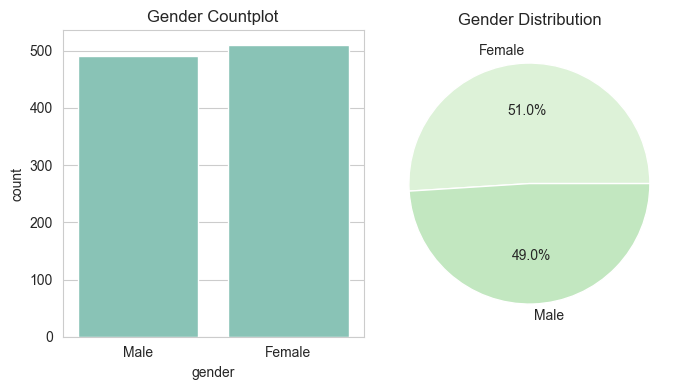

In [8]:
# Map a countplot and pie chart for gender variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), tight_layout=True)

sns.countplot(data=df_vis, x="gender", ax=axes[0], color="#7FCDBB")
axes[0].set_title("Gender Countplot")

axes[1].pie(
    df_vis["gender"].value_counts(),
    labels=df_vis["gender"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Gender Distribution")

plt.show()

Here, we can see that gender is fairly evenly distributed among the students.

#### **1.1.2 Parental Education**

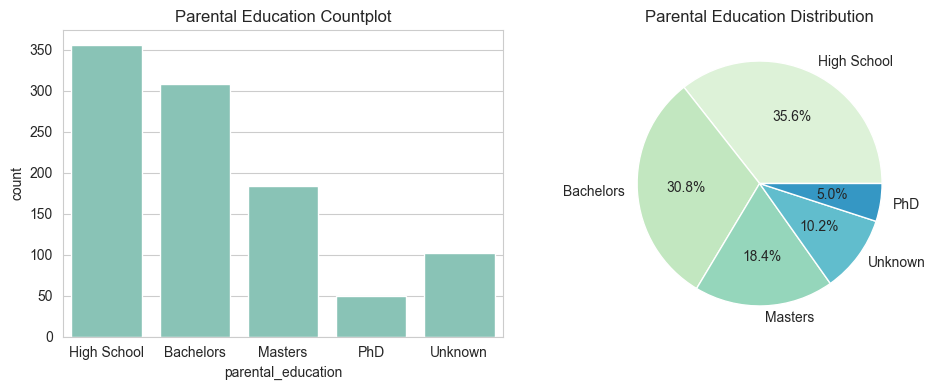

In [9]:
# Map a countplot and pie chart for parental_education variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)

# Set order of the parental_education variable to ensure "Unknown" is at the end
parental_education_order = [
    "High School",
    "Bachelors",
    "Masters",
    "PhD",
    "Unknown"
]

# Map the countplot
sns.countplot(data=df_vis, x="parental_education", order=parental_education_order, ax=axes[0], color="#7FCDBB")
axes[0].set_title("Parental Education Countplot")

# Map the pie chart
axes[1].pie(
    df_vis["parental_education"].value_counts(), 
    labels=df_vis["parental_education"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Parental Education Distribution")

plt.show()

#### **1.1.3 Internet Access**

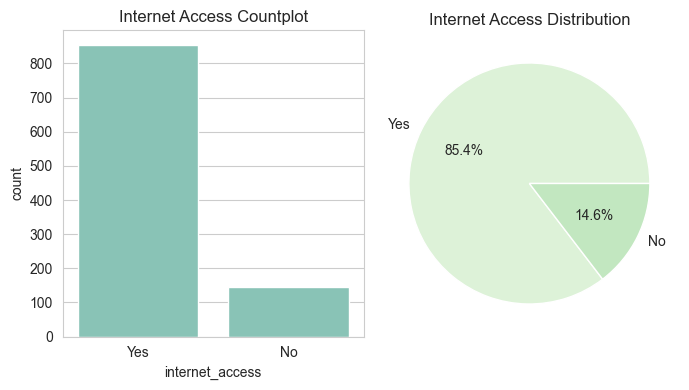

In [10]:
# Map a countplot and pie chart for internet_access variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), tight_layout=True)

# Countplot and Pie chart for "internet_access" variable
sns.countplot(data=df_vis, x="internet_access", ax=axes[0], color="#7FCDBB")
axes[0].set_title("Internet Access Countplot")

axes[1].pie(
    df_vis["internet_access"].value_counts(), 
    labels=df_vis["internet_access"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Internet Access Distribution")

plt.show()

We can see that the vast majority of students have internet access.

#### **1.1.4 Extracurricular Activities**

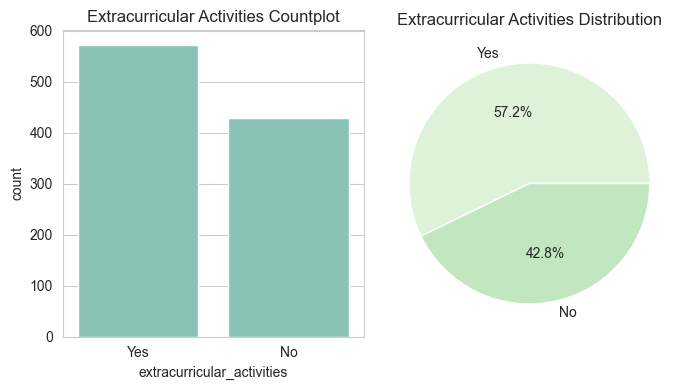

In [11]:
# Map a countplot and pie chart for extracurricular_activities variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), tight_layout=True)

sns.countplot(data=df_vis, x="extracurricular_activities", ax=axes[0], color="#7FCDBB")
axes[0].set_title("Extracurricular Activities Countplot")

axes[1].pie(
    df_vis["extracurricular_activities"].value_counts(), 
    labels=df_vis["extracurricular_activities"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Extracurricular Activities Distribution")

plt.show()

#### **1.1.5 Part Time Job**

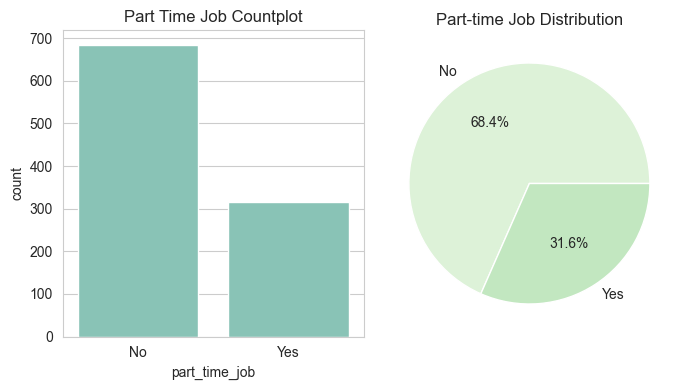

In [12]:
# Map a countplot and pie chart for extracurricular_activities variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), tight_layout=True)

sns.countplot(data=df_vis, x="part_time_job", ax=axes[0], color="#7FCDBB")
axes[0].set_title("Part Time Job Countplot")

axes[1].pie(
    df_vis["part_time_job"].value_counts(),
    labels=df_vis["part_time_job"].value_counts().index,
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Part-time Job Distribution")

plt.show()

#### **1.1.6 Final Grade**

As with `parental_education` above, we need to reorder the final letter grades to read `A`, `B`, `C`, `D`, `F`.

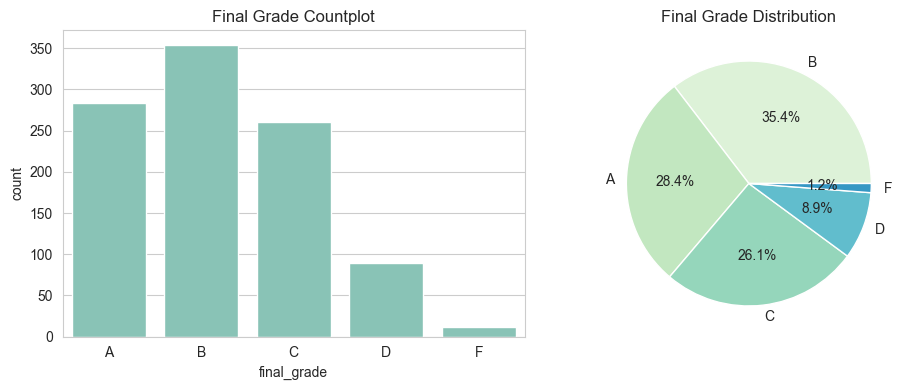

In [14]:
# Map a countplot and pie chart for final_grade variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)

# Set order of the final_grade variable 
final_grade_order = [
    "A",
    "B",
    "C",
    "D",
    "F"
]

sns.countplot(data=df_vis, x="final_grade", order=final_grade_order, ax=axes[0], color="#7FCDBB")
axes[0].set_title("Final Grade Countplot")

axes[1].pie(
    df_vis["final_grade"].value_counts(),
    labels=df_vis["final_grade"].value_counts().index,
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Final Grade Distribution")

plt.show()

### **1.2 Explore relationship between Final Grade and Final Exam Score**

In this section, I want to take a look at the last two columns: `final_exam_score` and `final_grade`.

Before going on to do any modelling, I want to ascertain the relationship between the values in these two columns.

#### **1.2.1 What is the distribution of exam scores within each letter grade?**

In [15]:
# Inspect the score ranges for each letter grade
df_vis.groupby("final_grade")["final_exam_score"].agg(
    ["min", "max", "count"]
)

,min,max,count
final_grade,,,
A,90.0,100.0,284
B,80.0,89.9,354
C,70.0,79.9,261
D,60.0,69.9,89
F,46.8,59.7,12


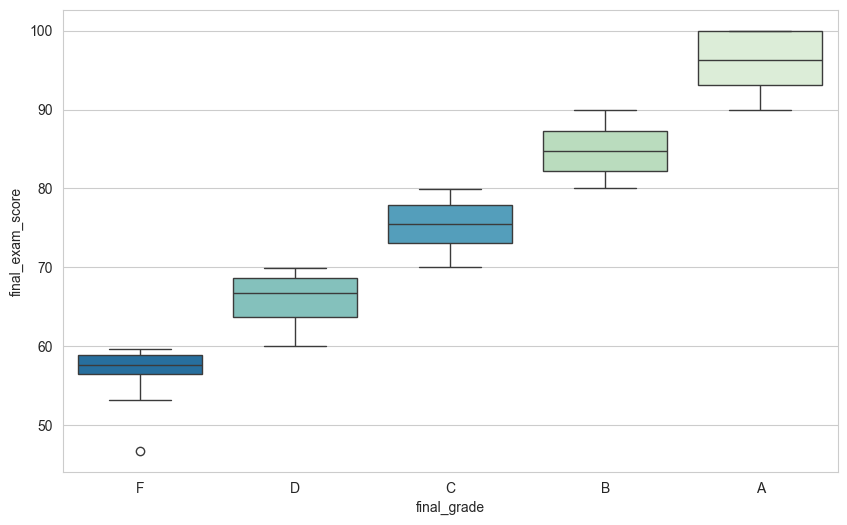

In [16]:
# Create a boxplot to visualise the distribution of exam scores for each letter grade

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_vis,
    x="final_grade",
    y="final_exam_score",
    order=["F", "D", "C", "B", "A"],
    hue="final_grade",
    legend=False,
    palette="GnBu")
plt.show()

Because we can see that there is no overlap in the scores and that the score ranges can progressively higher as the letter grade goes up (as is to be expected for grades), this demonstrates that the `final_grade` could indeed represent bins of the `final_exam_score`.

However, I want to explore this more by looking at a correlation test.

#### **1.2.2 Using Correlation Tests**

I will use a Spearman correlation test to look at the relationship between `final_grade` and `final_exam_score`.

I had a choice between two correlation tests - Spearman and Pearson - and chose Spearman for the below reasons:

*Pearson*:
* A Pearson's correlation measures a straight-line (linear) link
* It needs raw continuous data - **This is a problem because the `final_grade` is ordinal**

*Spearman*: 
* A Spearman correlation test measures a *monotonic link*.
    * This means that things move in the same general direction (up or down) but do not have to form a straight line.
* This correlation test works really well with ranked or score-based data - **This is positive for our investigation because grades are, indeed, ranked**.
* It is less impacted by outliers than a Pearson correlation test, which is much more sensitive.

A Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated.

To carry out a Spearman correlation test on the two columns, I will use the pandas method `.corr()`.

`.corr()` works on a DataFrame, so I will create a separate one containing the two columns. 

##### **Create a DataFrame to carry out the Correlation Tests**

In [17]:
# Create a correlation dataframe and map the final grade values to numerical equivalents
df_corr = df_vis[["final_exam_score", "final_grade"]].copy()

df_corr["final_grade"] = df_corr["final_grade"].map({
    "F": 0,
    "D": 1,
    "C": 2,
    "B": 3,
    "A": 4
})

df_corr.head()

,final_exam_score,final_grade
0,100.0,4
1,100.0,4
2,97.3,4
3,83.8,3
4,68.3,1


> *Troubleshooting Issues*:
<br><br>Very simple, but when I first completed this task, I kept getting an error `SettingWithCopyWarning`.
<br><br>This is because I did not include the `.copy()` method at the end.
<br><br>I wrongly assumed that because I had renamed the dataframe, that pandas would understand that this was a new dataframe to be created.
<br><br>By using `.copy()`, I was explicit in what I wanted and it meant that pandas was no longer unsure whether `df_corr` was a separate DataFrame or just a view of `df_vis`.
<br><br>Errors like these are excellent reminders of the need to be really clear about what steps you want to be taken.

##### **Carry out a Spearman Correlation**

In [18]:
# Use Spearman correlation test to analyse the relationship between final exam scores and final grades
df_corr.corr(method="spearman")

,final_exam_score,final_grade
final_exam_score,1.000000,0.956397
final_grade,0.956397,1.000000


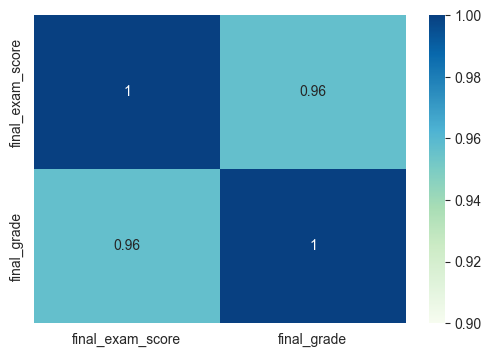

In [19]:
# Plot this Spearman correlation as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df_corr.corr(method="spearman"), annot=True, cmap="GnBu",vmin=0.9, vmax=1)
plt.show()

With a score of 0.96 for the correlation between the two, the Spearman test shows we have a very strong, **positive monotonic** relationship between `final_exam_score` and `final_grade`. 

*What is a Positive Monotonic Relationship?*: It means that as one thing goes up, the other thing always goes up too.

#### **1.2.3 Can the Final Grades be Predicted?**

By looking at **1.1.1**, we saw that the grades appeared to have defined ranges. 

Whilst some of the ranges were not completely defined (particularly grade "F", where the max value was 0.03 away from the minimum value for grade "D").

I believe the grades are bins of the final exam scores as follows:


| **Letter Grade** | **Final Exam Score** |
| --- | --- |
| A | >= 90.0 |
| B | >= 80.0 and < 90.0 |
| C | >= 70.0 and < 80.0 |
| D | >= 60.0 and < 70.0 |
| F | < 60 |

If this *was* the case, I want to look at my data and see if I get the same `final_grade` if I apply this rule above.

In [20]:
# Create a new dataframe that will store the new column for predicted grades
df_pred_grades = df_vis[["final_exam_score", "final_grade"]].copy()

Firstly, I am going to define a function - `predicted_grade()` - that is going to be used to process a numerical value (score) and will return a predicted letter grade based on the bins I have outlined in the intro to this section.

In [22]:
# Create a function to predict letter grades based on final exam scores
def predicted_grade(score):
    '''
    This function will take a numerical score as input and it will return
    a predicted letter grade based on a scale.
    '''
    if score >= 90:
        return "A"
    elif score >= 80:
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    else:
        return "F"

# Test the function with a sample score
print(f"Test of predicted grade function for score 85: {predicted_grade(85)}")

Test of predicted grade function for score 85: B


I'm now going to apply this function to the final exam scores found in the column `final_exam_scores`.

The process will be: 
* Creating a new column - `predicted_grade`
* This column will be filled with the predicted grades which are produced by applying the function `predicted_grade` to the scores in the final exam column
* I will use `.apply(predicted_grade)` to do this

In [23]:
# Create a new column for predicted grades and apply the predicted_grade function to the final_exam_score column
df_pred_grades["predicted_grade"] = df_pred_grades["final_exam_score"].apply(predicted_grade)

# Use .head() to display the first few rows of the dataframe with the new predicted_grade column
df_pred_grades.head()

,final_exam_score,final_grade,predicted_grade
0,100.0,A,A
1,100.0,A,A
2,97.3,A,A
3,83.8,B,B
4,68.3,D,D


Finally, I will look at the proportion of rows where the predicted grade exactly matches the original `final_grade`.

In [24]:
# Work out the accuracy of the predicted grades
accuracy_pred_grades = (df_pred_grades["predicted_grade"] == df_pred_grades["final_grade"]).mean()
print(f"The accuracy of the predicted grades is: {accuracy_pred_grades:.2%}")

The accuracy of the predicted grades is: 100.00%


#### **1.2.4 Summary**
Because of the strong correlation between `final_grade` and `final_exam_score`, the findings in this aspect of my EDA have been really useful in helping me make a decision when it come to the next section - **Stage 3 - ML**.

In that next section, I will be looking to use a machine learning model to predict `final_exam_score`. If I were to include `final_grade` as a feature in my train sets, I would end up with considerable *target leakage*. In other words, because `final_grade` is likely to be a discretised version of `final_exam_score`, I would essentially be training a model on a feature that is only available after the target is found. 

The model would perform well on the test data but would then fail with new real data (that would not have the `final_grade`).

---